In [ ]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [ ]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v01_version_para_regresion.csv'
#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas_brutas.csv'

dataset = '/content/drive/MyDrive/Colab Notebooks/data_v01_clustering_ventas.csv'

In [ ]:
#cargamos el dataset y mostramos las primeras filas
try:
    df = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/Colab Notebooks/data_v01_clustering_ventas.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice,IsWeekend,Sales_Lag_1,Sales_Lag_7,Sales_Mean_7,Sales_Mean_30,Trend_Lag1_vs_Lag7,DailyTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30,0,NaN,NaN,NaN,NaN,NaN,"57,442.33"
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,15.30,NaN,NaN,NaN,NaN,"57,442.33"
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00,0,20.34,NaN,NaN,NaN,NaN,"57,442.33"
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,22.00,NaN,NaN,NaN,NaN,"57,442.33"
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,20.34,NaN,NaN,NaN,NaN,"57,442.33"


In [ ]:
import pandas as pd
import numpy as np


print(f"Filas originales antes de limpieza: {len(df)}")

# FASE 1: LIMPIEZA DE DATOS

# Eliminar CustomerID nulos
df_clean = df.dropna(subset=['CustomerID']).copy()

# Eliminar Descripciones nulas
df_clean = df_clean.dropna(subset=['Description'])

# Eliminar Invoices Canceladas (Nos quedamos solo con las ventas)
# Asumimos que las cancelaciones tienen Quantity negativa o empiezan por 'C' en el InvoiceNo
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Convertir CustomerID a string
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# Convertir la fecha
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Calcular el TotalPrice de cada línea
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Eliminar las variables de regresión
columnas_regresion = ['Sales_Lag_1', 'Sales_Lag_7', 'Sales_Mean_7', 'Sales_Mean_30', 'dayOfweek', 'is_weekend', 'DailyTotal', 'Trend_Lag1_vs_Lag7', 'IsUk', 'DayOfWeek','IsWeekend']
columnas_a_borrar = [col for col in columnas_regresion if col in df_clean.columns]

if columnas_a_borrar:
    df_clean = df_clean.drop(columns=columnas_a_borrar)
    print(f"Columnas eliminadas: {columnas_a_borrar}")

print(f"Filas resultantes tras limpieza: {len(df_clean)}")
display(df_clean.head())

Filas originales antes de limpieza: 522010
Columnas eliminadas: ['Sales_Lag_1', 'Sales_Lag_7', 'Sales_Mean_7', 'Sales_Mean_30', 'DailyTotal', 'Trend_Lag1_vs_Lag7', 'IsUk', 'DayOfWeek', 'IsWeekend']
Filas resultantes tras limpieza: 390600


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom,1,12,2010,8,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom,1,12,2010,8,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom,1,12,2010,8,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom,1,12,2010,8,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom,1,12,2010,8,20.34


In [ ]:
import numpy as np
import pandas as pd


# FASE 2: FEATURE ENGINEERING

# 1. Preparación de variables temporales en el dataset limpio
fecha_referencia = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['Is_Weekend'] = np.where(df_clean['DayOfWeek'] >= 5, 1, 0)

# 2. Agrupación y creación de variables Core
df_usuarios = df_clean.groupby('CustomerID').agg({
    # RFM Básico
    'InvoiceDate': ['max', 'min'],                                    # Para Recency y Tenure
    'InvoiceNo': 'nunique',                                           # Frequency
    'TotalPrice': 'sum',                                              # Monetary

    # Diversidad y Volumen
    'StockCode': 'nunique',                                           # UniqueProducts
    'Quantity': 'sum',                                                # TotalQuantity

    # Patrones temporales y geografía
    'Is_Weekend': 'mean',                                             # % de compras en finde
    'DayOfWeek': lambda x: x.mode()[0] if not x.mode().empty else 0,  # Día favorito
    'Country': 'first'                                                # Para Is_UK
}).reset_index()

# Aplanamos los nombres de las columnas que vienen de usar varios aggregates
df_usuarios.columns = ['CustomerID', 'LastPurchase', 'FirstPurchase', 'Frequency',
                       'Monetary', 'UniqueProducts', 'TotalQuantity',
                       'Weekend_Ratio', 'Favorite_Day', 'Country']

# 3. Creación de variables calculadas¡

# RFM + Tenure
df_usuarios['Recency'] = (fecha_referencia - df_usuarios['LastPurchase']).dt.days
df_usuarios['Tenure'] = (fecha_referencia - df_usuarios['FirstPurchase']).dt.days

# Frecuencia avanzada y Ticket
df_usuarios['AverageOrderValue'] = df_usuarios['Monetary'] / df_usuarios['Frequency']
df_usuarios['AvgQuantityPerOrder'] = df_usuarios['TotalQuantity'] / df_usuarios['Frequency']
df_usuarios['Products_Per_Order'] = df_usuarios['UniqueProducts'] / df_usuarios['Frequency']

# Ciclo de compra (Evitamos dividir por cero en los que solo tienen 1 compra)
df_usuarios['Avg_Days_Between_Purchases'] = np.where(df_usuarios['Frequency'] > 1,
                                                     df_usuarios['Tenure'] / df_usuarios['Frequency'], 0)

# Variables categóricas/binarias
df_usuarios['Is_UK'] = np.where(df_usuarios['Country'] == 'United Kingdom', 1, 0)
df_usuarios['Weekend_Shopper'] = np.where(df_usuarios['Weekend_Ratio'] > 0.5, 1, 0) # Si >50% es finde

# Media mensual de compras (Calculamos meses activos reales)
meses_activos = df_clean.groupby('CustomerID')['InvoiceDate'].apply(lambda x: x.dt.to_period('M').nunique()).reset_index(name='ActiveMonths')
df_usuarios = pd.merge(df_usuarios, meses_activos, on='CustomerID', how='left')
df_usuarios['Monthly_Average_Spend'] = np.where(df_usuarios['ActiveMonths'] > 0,
                                                df_usuarios['Monetary'] / df_usuarios['ActiveMonths'], 0)

# 4. Limpieza final de columnas base que ya no sirven para el modelo, por ejemplo las fechas de last y first purchase porque están resumidas en recency y tenure. Tambien totalquantity porque ya tenemos monetary y avgquantityperOrder, y eso es solo ruido.
#Country tampoco nos sirve, porque solo queremos saber si es nacional o internacional.
columnas_a_borrar = ['LastPurchase', 'FirstPurchase', 'TotalQuantity', 'Weekend_Ratio', 'Country', 'ActiveMonths']
df_usuarios = df_usuarios.drop(columns=columnas_a_borrar)

# Asegurar que no hay infinitos ni nulos
df_usuarios = df_usuarios.replace([np.inf, -np.inf], 0).fillna(0)

print(f"Número de clientes listos para segmentar: {len(df_usuarios)}")
print(f"Número de variables predictivas: {len(df_usuarios.columns) - 1}")
display(df_usuarios.head())

Número de clientes listos para segmentar: 4333
Número de variables predictivas: 13


,CustomerID,Frequency,Monetary,UniqueProducts,Favorite_Day,Recency,Tenure,AverageOrderValue,AvgQuantityPerOrder,Products_Per_Order,Avg_Days_Between_Purchases,Is_UK,Weekend_Shopper,Monthly_Average_Spend
0,12347,7,"4,310.00",103,1,3,368,615.71,351.14,14.71,52.57,0,0,615.71
1,12348,4,"1,437.24",21,3,76,359,359.31,583.00,5.25,89.75,0,0,359.31
2,12349,1,"1,457.55",72,0,19,19,"1,457.55",630.00,72.00,0.00,0,0,"1,457.55"
3,12350,1,294.40,16,2,311,311,294.40,196.00,16.00,0.00,0,0,294.40
4,12352,7,"1,385.74",57,1,37,297,197.96,75.14,8.14,42.43,0,0,346.44


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
import pandas as pd


# FASE 3: CODIFICACIÓN CATEGÓRICA + OUTLIERS + ESCALADO

# ONE-HOT ENCODING
# Convertimos el "Día Favorito" (0-6) en columnas binarias separadas
print("Aplicando One-Hot Encoding a variables categóricas...")

df_usuarios = pd.get_dummies(df_usuarios, columns=['Favorite_Day'], prefix='FavDay', drop_first=False)
# Nota: get_dummies convierte a booleanos (True/False), los pasamos a enteros (1/0)
for col in df_usuarios.columns:
    if col.startswith('FavDay_'):
        df_usuarios[col] = df_usuarios[col].astype(int)

# Separar el CustomerID para que el algoritmo no lo use
clientes_id = df_usuarios['CustomerID']
datos_modelo = df_usuarios.drop(columns=['CustomerID'])

# DETECCIÓN DE OUTLIERS (Isolation Forest)
print("Buscando anomalías con Isolation Forest...")
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(datos_modelo)

mask_normales = (outlier_labels == 1)
datos_limpios = datos_modelo[mask_normales]
clientes_id_limpios = clientes_id[mask_normales].reset_index(drop=True)

print(f"-> Se han eliminado {len(datos_modelo) - len(datos_limpios)} clientes atípicos (outliers).")

# NORMALIZACIÓN (Robust Scaling)
print("Escalando variables con RobustScaler...")
scaler = RobustScaler()
datos_escalados = scaler.fit_transform(datos_limpios)

df_escalado = pd.DataFrame(datos_escalados, columns=datos_limpios.columns)
df_modelo_final = pd.concat([clientes_id_limpios, df_escalado], axis=1)

print("-> ¡Datos listos y escalados con éxito!")
display(df_modelo_final.head())

Aplicando One-Hot Encoding a variables categóricas...
Buscando anomalías con Isolation Forest...
-> Se han eliminado 217 clientes atípicos (outliers).
Escalando variables con RobustScaler...
-> ¡Datos listos y escalados con éxito!


,CustomerID,Frequency,Monetary,UniqueProducts,Recency,Tenure,AverageOrderValue,AvgQuantityPerOrder,Products_Per_Order,Avg_Days_Between_Purchases,Is_UK,Weekend_Shopper,Monthly_Average_Spend,FavDay_0,FavDay_1,FavDay_2,FavDay_3,FavDay_4,FavDay_6
0,12347,1.67,3.24,1.19,-0.39,0.57,1.50,1.20,0.05,0.27,-1.00,0.00,1.09,0.00,1.00,0.00,0.00,0.00,0.00
1,12348,0.67,0.72,-0.22,0.19,0.52,0.37,2.62,-0.57,0.78,-1.00,0.00,0.18,0.00,0.00,0.00,1.00,0.00,0.00
2,12350,-0.33,-0.29,-0.31,2.06,0.30,0.09,0.26,0.13,-0.45,-1.00,0.00,-0.06,0.00,0.00,1.00,0.00,0.00,0.00
3,12352,1.67,0.67,0.40,-0.12,0.23,-0.34,-0.48,-0.38,0.13,-1.00,0.00,0.13,0.00,1.00,0.00,0.00,0.00,0.00
4,12353,-0.33,-0.47,-0.52,1.21,-0.20,-0.82,-0.81,-0.66,-0.45,-1.00,0.00,-0.79,0.00,0.00,0.00,1.00,0.00,0.00


Evaluando K-Means con diferentes valores de K...


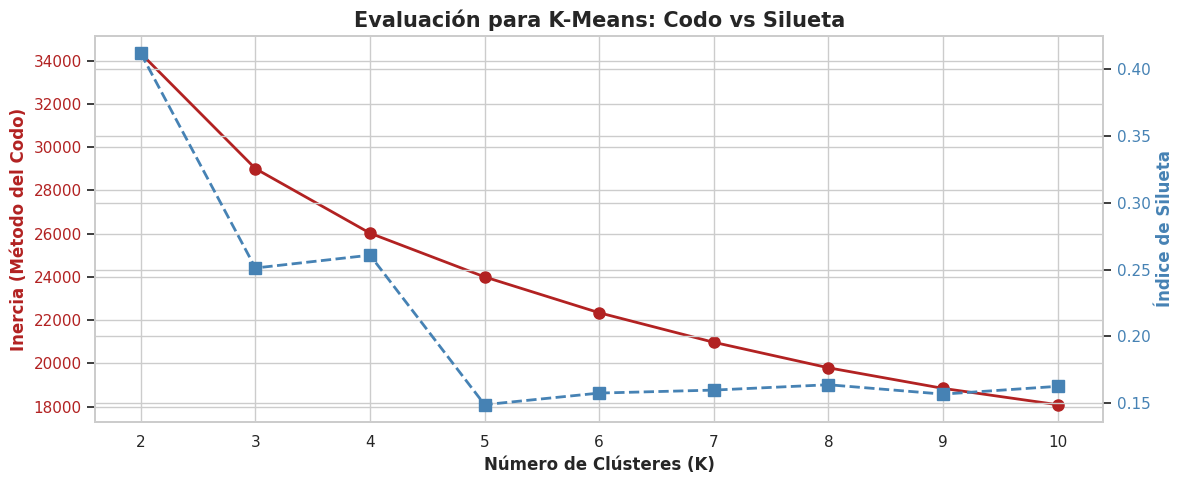

K=2 -> Índice de Silueta: 0.4116
K=3 -> Índice de Silueta: 0.2511
K=4 -> Índice de Silueta: 0.2607
K=5 -> Índice de Silueta: 0.1490
K=6 -> Índice de Silueta: 0.1576
K=7 -> Índice de Silueta: 0.1599
K=8 -> Índice de Silueta: 0.1639
K=9 -> Índice de Silueta: 0.1569
K=10 -> Índice de Silueta: 0.1627


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


# BUSCANDO EL NÚMERO ÓPTIMO DE CLÚSTERES (K-MEANS)
# Entrenamos sobre el espacio original (datos_escalados)

print("Evaluando K-Means con diferentes valores de K...")

datos_para_entrenar = df_escalado.copy()

inercia = []
siluetas = []
rango_k = range(2, 11) # Vamos a probar desde 2 hasta 10 perfiles de clientes

for k in rango_k:
    # Entrenamos K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(datos_para_entrenar)

    # Guardamos la inercia
    inercia.append(kmeans.inertia_)

    # Guardamos la silueta
    score = silhouette_score(datos_para_entrenar, etiquetas)
    siluetas.append(score)


# VISUALIZACIÓN DE MÉTRICAS (CODO Y SILUETA)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 5))

# Gráfico del Método del Codo (Eje Izquierdo - Rojo)
color1 = 'firebrick'
ax1.set_xlabel('Número de Clústeres (K)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inercia (Método del Codo)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(rango_k, inercia, marker='o', color=color1, linewidth=2, markersize=8, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color1)

# Gráfico del Índice de Silueta (Eje Derecho - Azul)
ax2 = ax1.twinx()
color2 = 'steelblue'
ax2.set_ylabel('Índice de Silueta', color=color2, fontsize=12, fontweight='bold')
ax2.plot(rango_k, siluetas, marker='s', linestyle='--', color=color2, linewidth=2, markersize=8, label='Silueta')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Evaluación para K-Means: Codo vs Silueta', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

# Mostrar los valores de silueta en texto para mayor claridad
for k, sil in zip(rango_k, siluetas):
    print(f"K={k} -> Índice de Silueta: {sil:.4f}")

In [ ]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

# Definimos nuestro K óptimo basado en el gráfico
K_OPTIMO = 4

print(f" ENTRENANDO MODELOS CON K={K_OPTIMO} ")

# 1. K-MEANS

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_escalado)
sil_kmeans = silhouette_score(df_escalado, labels_kmeans)
print(f"K-Means -> Índice de Silueta: {sil_kmeans:.4f}")


# 2. CLUSTERING JERÁRQUICO (Agglomerative)

# Usamos 'ward' que minimiza la varianza dentro de los clústeres (similar a K-Means)
jerarquico = AgglomerativeClustering(n_clusters=K_OPTIMO, linkage='ward')
labels_jerarquico = jerarquico.fit_predict(df_escalado)
sil_jerarquico = silhouette_score(df_escalado, labels_jerarquico)
print(f" Jerárquico -> Índice de Silueta: {sil_jerarquico:.4f}")


# Añadimos la etiqueta del clúster al dataset original LIMPIO (el que tiene los números reales)
df_resultados = df_usuarios.loc[df_modelo_final.index].copy()
df_resultados['Cluster_KMeans'] = labels_kmeans

print("\n-> Modelos entrenados y evaluados correctamente")

 ENTRENANDO MODELOS CON K=4 
K-Means -> Índice de Silueta: 0.2607
 Jerárquico -> Índice de Silueta: 0.1800

-> Modelos entrenados y evaluados correctamente


Aplicando PCA para reducir a 3 dimensiones...
-> Varianza explicada por los 3 componentes: 73.12%


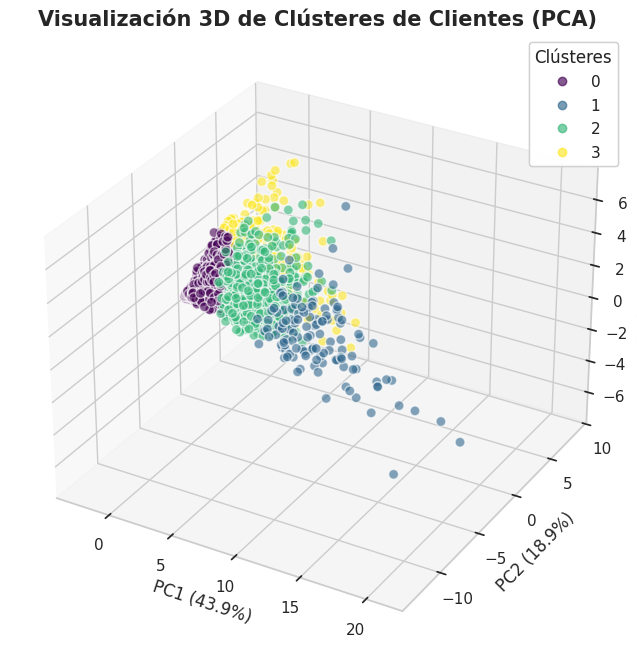


Generando tabla de perfiles de negocio 


,Frequency,Monetary,Recency,Tenure,AverageOrderValue,Is_UK,Weekend_Shopper,Num_Clientes
Cluster_KMeans,,,,,,,,
0,2.17,464.33,117.80,206.72,217.39,0.92,0.12,2513
1,19.42,"7,927.53",14.61,350.84,476.36,0.97,0.01,130
2,8.21,"2,767.56",28.32,308.04,357.42,0.92,0.08,672
3,2.14,"1,179.75",87.31,174.23,561.22,0.90,0.12,801


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


#  REDUCCIÓN DE DIMENSIONALIDAD (Solo para visualización)
print("Aplicando PCA para reducir a 3 dimensiones...")

# Usamos 3 componentes
pca = PCA(n_components=3, random_state=42)
datos_pca = pca.fit_transform(df_escalado)

# Calculamos la varianza explicada
varianza_explicada = pca.explained_variance_ratio_.sum() * 100
print(f"-> Varianza explicada por los 3 componentes: {varianza_explicada:.2f}%")


# VISUALIZACIÓN EN 3D DE LOS CLÚSTERES

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extraemos las coordenadas X, Y, Z
x = datos_pca[:, 0]
y = datos_pca[:, 1]
z = datos_pca[:, 2]

# Pintamos los puntos, coloreados por la etiqueta que nos dio K-Means
scatter = ax.scatter(x, y, z, c=df_resultados['Cluster_KMeans'], cmap='viridis', s=50, alpha=0.6, edgecolors='w')

ax.set_title('Visualización 3D de Clústeres de Clientes (PCA)', fontsize=15, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')

# Añadimos la leyenda
legend1 = ax.legend(*scatter.legend_elements(), title="Clústeres")
ax.add_artist(legend1)

plt.show()


# INTERPRETACIÓN DE NEGOCIO SEGURA
print("\nGenerando tabla de perfiles de negocio ")

# Creamos un dataframe seguro emparejando el ID exacto del cliente limpio con su clúster
resultados_seguros = pd.DataFrame({
    'CustomerID': clientes_id_limpios,
    'Cluster_KMeans': labels_kmeans
})

# Lo unimos a nuestro dataset de usuarios ORIGINAL (sin escalar) usando el CustomerID
df_resultados_corregido = pd.merge(df_usuarios, resultados_seguros, on='CustomerID', how='inner')

# Seleccionamos las columnas clave de negocio
columnas_negocio = ['Frequency', 'Monetary', 'Recency', 'Tenure', 'AverageOrderValue', 'Is_UK', 'Weekend_Shopper']

# Agrupamos y calculamos la media real
perfil_clusters = df_resultados_corregido.groupby('Cluster_KMeans')[columnas_negocio].mean().round(2)

# Añadimos el conteo de clientes
perfil_clusters['Num_Clientes'] = df_resultados_corregido['Cluster_KMeans'].value_counts()

display(perfil_clusters)